# California Solar Generation and Grid CO₂ Intensity

## Scientific Question: 
California has dramatically increased its share of solar generation since 2014. Does the relationship between solar energy share and grid CO₂ intensity in California weaken during winter months, when solar generation is reduced?

## Hypothesis
The regression slopes between solar energy share and grid CO₂ intensity will be weaker in winter than in summer, because lower solar output increases the need for backup fossil fuel generation.

## Data Sources
**EIA**: Monthly state-level generation by energy source, [eia.gov/electricity/data.php](https://www.eia.gov/electricity/data.php)

**CAISO**: Monthly historical CO₂ emissions, [caiso.com/todays-outlook/emissions](https://www.caiso.com/todays-outlook/emissions#section-historical-co2-trend)

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Methods

This analysis combines two datasets to calculate monthly carbon intensity and solar energy share for California from 2014–2025. 

**Solar energy share** is calculated as:

$$\text{Solar Share} = \frac{\text{Solar Generation (MWh)}}{\text{Total Generation (MWh)}}$$

**CO₂ intensity** is calculated as:

$$\text{CO}_2 \text{ Intensity} = \frac{\text{Total CO}_2 \text{ Emissions (metric tons)}}{\text{Total Generation (MWh)}}$$

To test the hypothesis, I fit an Ordinary Least Squares (OLS) regression for each season:

$$\text{CO}_2 \text{ Intensity} = \alpha + \beta \cdot \text{Solar Share} + \epsilon$$

In this equation, $\beta$ is the slope that will answer my hypothesis. A more negative $\beta$ indicates that solar share has a stronger impact on reducing CO₂ intensity. I will compare $\beta$ across winter (December-February) and summer (June-August) to test whether the relationship weakens in winter.

## Load EIA Generation Data
This data set was downloaded from the U.S. Energy Information Administration. It provides monthly state-level electricity generation by energy source. The dataset covers all 50 states from 2001 to present and breaks down generation into energy source and producer type. For the purposes of this analysis, I filtered to California and the "Total Electric Power Industry" sector.

In [75]:
import io

xl = pd.ExcelFile("generation_monthly (2).xlsx")
sheets = [s for s in xl.sheet_names if "Final" in s or "Preliminary" in s]

dfs = []
for sheet in sheets:
    df_sheet = xl.parse(sheet)
    df_sheet.columns = ["YEAR", "MONTH", "STATE", "TYPE OF PRODUCER", 
                        "ENERGY SOURCE", "GENERATION (Megawatthours)"]
    dfs.append(df_sheet)

eia_raw = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(eia_raw)}")
print(eia_raw.head(3))

Total rows: 353857
                                                YEAR MONTH STATE  \
0  Monthly Generation Data by State, Producer Sec...   NaN   NaN   
1                            Sources: EIA-923 Report   NaN   NaN   
2                                                NaN   NaN   NaN   

  TYPE OF PRODUCER ENERGY SOURCE GENERATION (Megawatthours)  
0              NaN           NaN                        NaN  
1              NaN           NaN                        NaN  
2              NaN           NaN                        NaN  


/opt/sw/anaconda3/2023.09/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


## Filter to California Solar and Total Generation

In [46]:
print(eia_raw.columns.tolist())
print(eia_raw.head(3))

['YEAR', 'MONTH', 'STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE', 'GENERATION (Megawatthours)']
                                                YEAR MONTH STATE  \
0  Monthly Generation Data by State, Producer Sec...   NaN   NaN   
1                            Sources: EIA-923 Report   NaN   NaN   
2                                                NaN   NaN   NaN   

  TYPE OF PRODUCER ENERGY SOURCE GENERATION (Megawatthours)  
0              NaN           NaN                        NaN  
1              NaN           NaN                        NaN  
2              NaN           NaN                        NaN  


In [47]:
ca = eia_raw[eia_raw["STATE"] == "CA"].copy()
ca = ca[ca["TYPE OF PRODUCER"] == "Total Electric Power Industry"]

solar = ca[ca["ENERGY SOURCE"] == "Solar Thermal and Photovoltaic"][
    ["YEAR", "MONTH", "GENERATION (Megawatthours)"]
].copy().rename(columns={"GENERATION (Megawatthours)": "solar_MWh"})

total = ca[ca["ENERGY SOURCE"] == "Total"][
    ["YEAR", "MONTH", "GENERATION (Megawatthours)"]
].copy().rename(columns={"GENERATION (Megawatthours)": "total_MWh"})

eia = solar.merge(total, on=["YEAR", "MONTH"])
eia["date"] = pd.to_datetime(eia["YEAR"].astype(str) + "-" + eia["MONTH"].astype(str) + "-01")
eia = eia.set_index("date").sort_index()
eia["solar_share"] = eia["solar_MWh"] / eia["total_MWh"]
eia = eia[eia.index >= "2014-01-01"]

print(eia[["solar_MWh", "total_MWh", "solar_share"]].head(12))

             solar_MWh    total_MWh solar_share
date                                           
2014-01-01   388107.97  15662855.12    0.024779
2014-02-01   435554.99  13997302.28    0.031117
2014-03-01   729313.22  14155157.36    0.051523
2014-04-01    877334.7  15231379.11      0.0576
2014-05-01   1005613.6  16446861.52    0.061143
2014-06-01  1092433.79  16979074.92     0.06434
2014-07-01    990472.6  19894734.45    0.049786
2014-08-01  1064335.87  19359860.62    0.054976
2014-09-01  1045279.46  18983516.23    0.055062
2014-10-01   929166.91  17541895.34    0.052968
2014-11-01   768633.86   14483217.1    0.053071
2014-12-01   564701.04  14968888.01    0.037725


## Load CAISO CO₂ Emissions Data
This dataset was downloaded from the California Independent System Operator (CAISO), which manages approximately 80% of California's electricity grid, and provides monthly CO₂ emissions data for this territory. The provided dataset covers 2014–2025 and reports total CO₂ emissions in metric tons per month. Since CAISO does not technically cover all of California while the EIA data does, the CO₂ intensity values computed here are an approximation. 

In [14]:
caiso_wide = pd.read_csv("CAISO-historical-co2-20260407.csv", header=0)

caiso_wide.columns = ["year", "Jan", "Feb", "Mar", "Apr", "May", "Jun",
                      "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

caiso_wide = caiso_wide[pd.to_numeric(caiso_wide["year"], errors="coerce").notna()]
caiso_wide["year"] = caiso_wide["year"].astype(int)

caiso_long = caiso_wide.melt(id_vars="year", var_name="month_str", value_name="co2_tons")

month_map = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,
             "Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}
caiso_long["month"] = caiso_long["month_str"].map(month_map)
caiso_long["date"] = pd.to_datetime({"year": caiso_long["year"], "month": caiso_long["month"], "day": 1})
caiso_long = caiso_long.set_index("date")[["co2_tons"]].dropna().sort_index()

print(caiso_long.head(12))

               co2_tons
date                   
2014-01-01  5615497.820
2014-02-01  5022762.297
2014-03-01  5289480.524
2014-04-01  4812433.460
2014-05-01  5331965.630
2014-06-01  5451151.875
2014-07-01  6904019.904
2014-08-01  6760966.430
2014-09-01  6619994.447
2014-10-01  6314691.774
2014-11-01  5162069.020
2014-12-01  5495698.799


In [12]:
import os
print(os.listdir())

['.git', 'unix-assignment', 'Data Formats and Access Assignment.ipynb', 'InClassNotebooks', 'Readme.md', 'Basic Python Assignment.ipynb', '.ipynb_checkpoints', 'Untitled.ipynb', 'MoreMatplotlib.ipynb', 'Numpy and Matplotlib.ipynb', 'Pandas_Fundamentals.ipynb', 'Untitled1.ipynb', 'Pandas groupby Assignment.ipynb', 'Untitled2.ipynb', 'Xarray Fundamentals.ipynb', 'Untitled3.ipynb', 'Untitled4.ipynb', 'CAISO-historical-co2-20260407.csv', 'CAISO.ipynb']


## Merge and Compute CO₂ Intensity
The two datasets are joined on their date index (year and month). CO₂ intensity is then computed by dividing CAISO monthly emissions by EIA total generation. 

In [58]:
eia.index.name = "date"
caiso_long.index.name = "date"

df = eia[["solar_share", "total_MWh"]].join(caiso_long[["co2_tons"]], how="inner").dropna()
df["co2_intensity"] = df["co2_tons"] / df["total_MWh"]

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["month"]  = df.index.month
df["year"]   = df.index.year
df["season"] = df["month"].map(get_season)

print(df[["solar_share", "co2_intensity", "season"]].head(12))
print(f"\n{len(df)} months total, {df.index.min().date()} to {df.index.max().date()}")

           solar_share co2_intensity  season
date                                        
2014-01-01    0.024779      0.358523  Winter
2014-02-01    0.031117      0.358838  Winter
2014-03-01    0.051523      0.373679  Spring
2014-04-01      0.0576      0.315955  Spring
2014-05-01    0.061143      0.324194  Spring
2014-06-01     0.06434      0.321051  Summer
2014-07-01    0.049786      0.347027  Summer
2014-08-01    0.054976      0.349226  Summer
2014-09-01    0.055062      0.348723    Fall
2014-10-01    0.052968      0.359978    Fall
2014-11-01    0.053071      0.356417    Fall
2014-12-01    0.037725      0.367141  Winter

144 months total, 2014-01-01 to 2025-12-01


## Compute Seasonal Regression Slopes
For this analysis, I fit a separate OLS regression for each season, regressing CO₂ intensity on solar share. The slope $\beta$ represents how much CO₂ intensity decreases for each additional unit of solar penetration. The closer the slope is to zero, the weaker the relationship is.

In [76]:
season_colors = {
    "Winter": "blue",
    "Spring": "green",
    "Summer": "red",
    "Fall":   "purple"
}

def manual_linregress(x, y):
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
    intercept = y_mean - slope * x_mean
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y_mean)**2)
    r2 = 1 - ss_res / ss_tot
    se = np.sqrt(ss_res / (n - 2) / np.sum((x - x_mean)**2))
    t_stat = slope / se
    from scipy.stats import t
    p = 2 * t.sf(np.abs(t_stat), df=n - 2)
    t_crit = t.ppf(0.975, df=n - 2)
    return {
        "slope":     slope,
        "intercept": intercept,
        "r2":        r2,
        "p":         p,
        "slope_lo":  slope - t_crit * se,
        "slope_hi":  slope + t_crit * se,
    }

season_stats = {}
for season in season_colors:
    sub = df[df["season"] == season].dropna(subset=["solar_share", "co2_intensity"])
    x = sub["solar_share"].values.astype(float)
    y = sub["co2_intensity"].values.astype(float)
    season_stats[season] = manual_linregress(x, y)

for s, v in season_stats.items():
    print(f"{s}: slope={v['slope']:.4f}, R²={v['r2']:.2f}, p={v['p']:.4f}")

Winter: slope=-0.7686, R²=0.54, p=0.0000
Spring: slope=-0.7792, R²=0.72, p=0.0000
Summer: slope=-0.7261, R²=0.83, p=0.0000
Fall: slope=-0.7060, R²=0.84, p=0.0000


## Figure 1: Solar Share and CO₂ Intensity Over Time

Figure #1 compares the monthly time series of solar share and CO₂ intensity from 2014-2025. There is a clear inverse relationship between the two variables, indicating that as solar share increases over time, CO₂ intensity decreases. Furthermore, there are seasonal cycles with both variables. Solar during the summer while CO₂ intensity peaks during the winter.

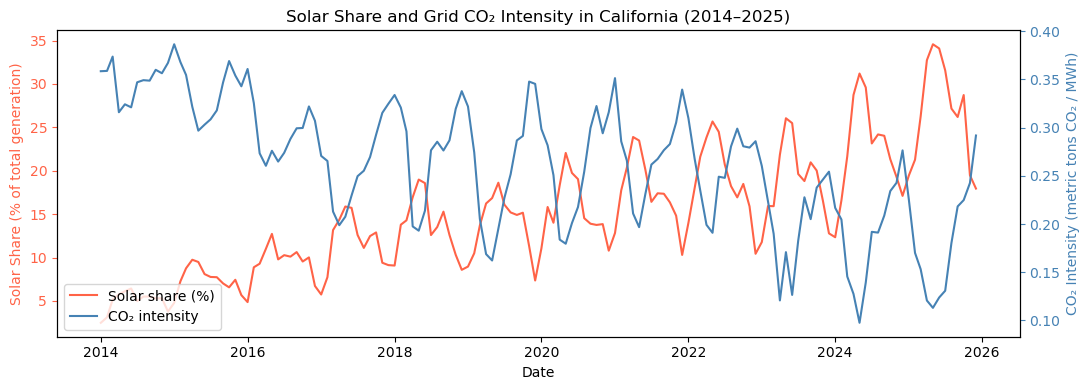

In [77]:
fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

ax1.plot(df.index, df["solar_share"] * 100, color="tomato", label="Solar share (%)")
ax2.plot(df.index, df["co2_intensity"], color="steelblue", label="CO₂ intensity")

ax1.set_ylabel("Solar Share (% of total generation)", color="tomato")
ax2.set_ylabel("CO₂ Intensity (metric tons CO₂ / MWh)", color="steelblue")
ax1.tick_params(axis="y", colors="tomato")
ax2.tick_params(axis="y", colors="steelblue")
ax1.set_xlabel("Date")
ax1.set_title("Solar Share and Grid CO₂ Intensity in California (2014–2025)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.savefig("fig1_time_series.png")
plt.show()

## Figure 2: Solar Share vs. CO₂ Intensity by Season
In Figure #2, each point represents one month and is color-coded by season. Separate OLS regression lines are fit for each season. If the regression slopes between solar energy share and grid CO₂ intensity are weaker in winter than in summer, the winter regression line would be closer to horizontal than the summer line. This result would support my hypothesis, but is not the case.

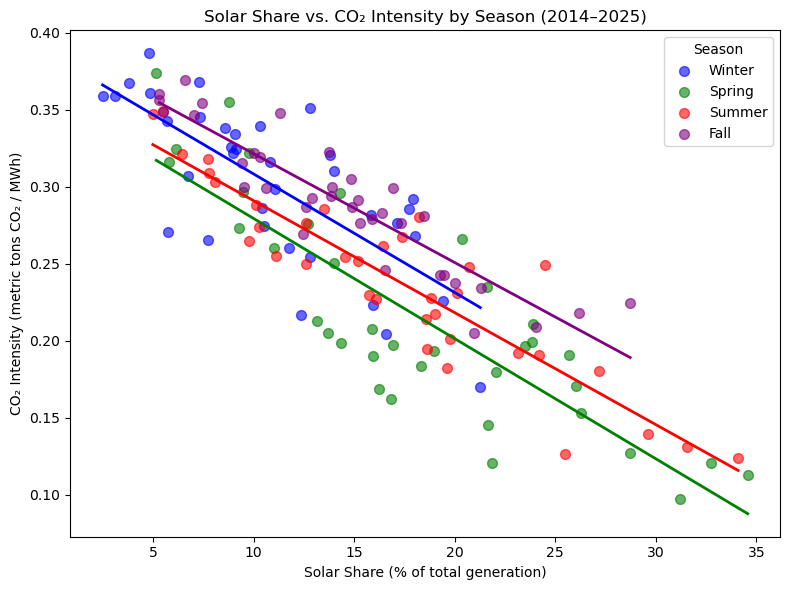

In [78]:
fig, ax = plt.subplots(figsize=(8, 6))

for season, color in season_colors.items():
    sub = df[df["season"] == season]
    st  = season_stats[season]
    ax.scatter(sub["solar_share"] * 100, sub["co2_intensity"],
               color=color, alpha=0.6, s=50, label=season)
    x_range = np.linspace(sub["solar_share"].min(), sub["solar_share"].max(), 100)
    ax.plot(x_range * 100, st["intercept"] + st["slope"] * x_range, color=color, lw=2)

ax.set_xlabel("Solar Share (% of total generation)")
ax.set_ylabel("CO₂ Intensity (metric tons CO₂ / MWh)")
ax.set_title("Solar Share vs. CO₂ Intensity by Season (2014–2025)")
ax.legend(title="Season")

plt.tight_layout()
plt.savefig("fig2_scatter.png")
plt.show()

## Figure 3: Regression Slope by Season
This figure compares the regression slopes across seasons, with 95% confidence intervals shown as error bars. The slopes that do not overlap in their confidence intervals indicate a statistically significant difference between seasons. As shown in the figure, this is not the case for any of the seasons.

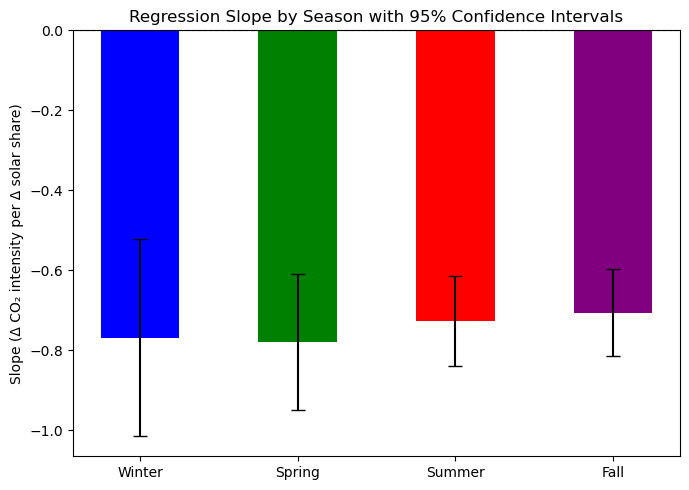

In [79]:
fig, ax = plt.subplots(figsize=(7, 5))

seasons = list(season_colors.keys())
colors  = list(season_colors.values())
slopes  = [season_stats[s]["slope"] for s in seasons]
errs    = [season_stats[s]["slope"] - season_stats[s]["slope_lo"] for s in seasons]

ax.bar(seasons, slopes, color=colors, width=0.5,
       yerr=errs, capsize=5, error_kw={"elinewidth": 1.5})
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_ylabel("Slope (Δ CO₂ intensity per Δ solar share)")
ax.set_title("Regression Slope by Season with 95% Confidence Intervals")

plt.tight_layout()
plt.savefig("fig3_slopes.png")
plt.show()

## Figure 4: Monthly Climatology of Solar Share and CO₂ Intensity
Figure #4 shows the monthly climatology, whichis the average value of each variable for each calendar month, averaged across all years in the dataset. This figure visualizes the seasonal cycles behind my analysis, where solar share peaks in spring and summer while CO₂ intensity peaks in winter.

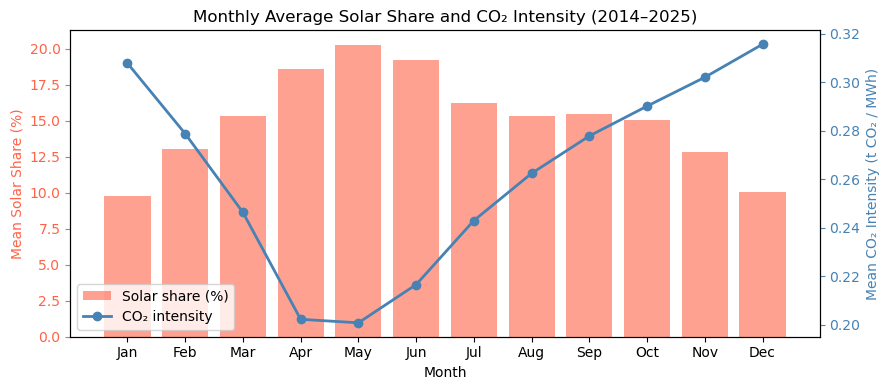

In [80]:
clim = df.groupby("month")[["solar_share", "co2_intensity"]].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.bar(clim.index, clim["solar_share"] * 100, color="tomato", alpha=0.6, label="Solar share (%)")
ax2.plot(clim.index, clim["co2_intensity"], color="steelblue", marker="o", lw=2, label="CO₂ intensity")

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_labels)
ax1.set_ylabel("Mean Solar Share (%)", color="tomato")
ax2.set_ylabel("Mean CO₂ Intensity (t CO₂ / MWh)", color="steelblue")
ax1.tick_params(axis="y", colors="tomato")
ax2.tick_params(axis="y", colors="steelblue")
ax1.set_xlabel("Month")
ax1.set_title("Monthly Average Solar Share and CO₂ Intensity (2014–2025)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.savefig("fig4_climatology.png")
plt.show()

## Figure 5: Residuals from Seasonal Regressions Over Time
The regression line for each season predicts what CO₂ intensity should be given a certain solar share. In equation form, this means that the residual for any given month is actual CO₂ intensity − predicted CO₂ intensity. Therefore, if a dot is above zero, it had a higher CO₂ intensity than expected, but if it is below zero, it had lower CO₂ intensity than expected. Therefore, if the dots are drifting over time, the relationship between solar share and CO₂ intensity is changing. When the dots are moving downward, that means that California's carbon emissions are reducing beyond what solar alone would explain. In this analysis, the dots are randomly scattered, which indicates that the regression model is capturing the relationship well. Some of the winter months show positive residuals, which means that CO₂ intensity was higher than predicted during those months. 

/tmp/ipykernel_311772/3962165175.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.00746618282664685 -0.002279980740280463 0.011102448327855785
 0.03814457929617088 0.03876069127837212 0.0013798217422652526
 0.013171023364513479 0.008628074898320404 -0.026313051942528476
 -0.07027498000434407 -0.060228423024355715 0.009808204254635466
 0.018561076346955863 0.04168410210504059 0.018728120075646337
 0.005715039109734643 -0.030045222568837793 0.016832510214692342
 -0.001597660644867549 0.01820554856853851 0.013845592030179765
 0.06482208362097697 0.03703906864635026 0.03357067110945422
 0.032282256424674804 0.021229640319480325 -0.01896581241811457
 -0.03424556551880997 -0.03941866562228616 -0.03248706764717929
 -0.07345572034446513 -0.05283090277950653 0.02279845987442325
 -0.009865221701372912 -0.0515446549249691 0.044710101100281396]' has dtype incompatible with float64, please explicitly cast to a

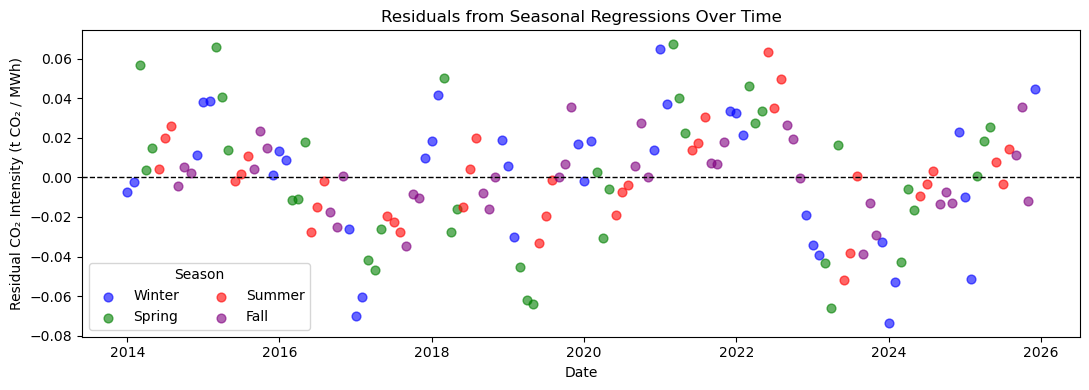

In [81]:
df["resid"] = 0.0
for season, st in season_stats.items():
    mask = df["season"] == season
    df.loc[mask, "resid"] = (
        df.loc[mask, "co2_intensity"]
        - (st["intercept"] + st["slope"] * df.loc[mask, "solar_share"])
    )

fig, ax = plt.subplots(figsize=(11, 4))
for season, color in season_colors.items():
    sub = df[df["season"] == season].sort_index()
    ax.scatter(sub.index, sub["resid"], color=color, alpha=0.6, s=40, label=season)

ax.axhline(0, color="black", lw=1, linestyle="--")
ax.set_ylabel("Residual CO₂ Intensity (t CO₂ / MWh)")
ax.set_xlabel("Date")
ax.set_title("Residuals from Seasonal Regressions Over Time")
ax.legend(title="Season", ncol=2)

plt.tight_layout()
plt.savefig("fig5_residuals.png")
plt.show()

## Figure 6: Winter vs. Summer Regression Slopes by Year
Figure #6 shows how the winter and summer regression slopes evolve as more years of data are added. To do this, it uses an expanding window, which means that each point adds one more year over time until it uses all of the data in 2025. The projection reveals that the relationship between seasons has not been stable over time. In earlier years, summer showed a steeper slope than winter, which is consistent with my hypothesis. However, the two lines converge and cross in later years which means that the relationship flipped at some point, and winter's slope became steeper than summer's. This is likely due to the build-out of battery storage and grid infrastructure, which strengthened the share of solar generation in winter over time. 

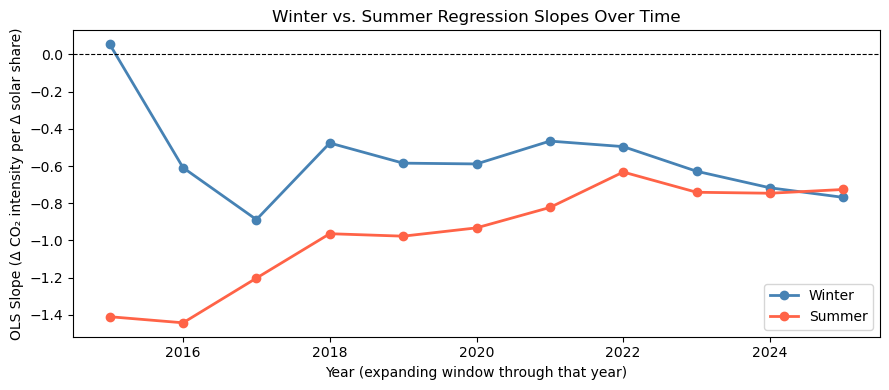

In [82]:
years = sorted(df["year"].unique())
results     = {"Winter": [], "Summer": []}
valid_years = {"Winter": [], "Summer": []}

for yr in years:
    for season in ["Winter", "Summer"]:
        sub = df[(df["season"] == season) & (df["year"] <= yr)].dropna(subset=["solar_share", "co2_intensity"])
        if len(sub) >= 4:
            x = sub["solar_share"].values.astype(float)
            y = sub["co2_intensity"].values.astype(float)
            st = manual_linregress(x, y)
            results[season].append(st["slope"])
            valid_years[season].append(yr)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(valid_years["Winter"], results["Winter"], color="steelblue", marker="o", lw=2, label="Winter")
ax.plot(valid_years["Summer"], results["Summer"], color="tomato",    marker="o", lw=2, label="Summer")
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_xlabel("Year (expanding window through that year)")
ax.set_ylabel("OLS Slope (Δ CO₂ intensity per Δ solar share)")
ax.set_title("Winter vs. Summer Regression Slopes Over Time")
ax.legend()

plt.tight_layout()
plt.savefig("fig6_slope_evolution.png")
plt.show()